# ViT-Tiny на CIFAR-10

Vision Transformer (Dosovitskiy et al., 2020) из примитивов `spartan_torch`:

1. **Проверка примитивов.** `PatchEmbedding`, `ClassToken`, `LearnablePositionEmbedding` + существующий `TransformerBlock` собираются в полный ViT.
2. **Совместимость с timm.** Pretrained веса timm `vit_base_patch16_224` загружаются через remap (см. `timm_compat/check_weights.py`).
3. **Трейн-пайплайн.** pytorch-lightning, CIFAR-10, cosine LR + warmup.

Запуск: `uv sync --extra dev --extra experiments`, затем `uv run jupyter lab`.

## 0. Конфигурация

In [1]:
from pathlib import Path

import torch

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
CKPT_DIR = ROOT / "checkpoints"
DATA_DIR.mkdir(exist_ok=True)
CKPT_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"cwd: {ROOT} | device: {DEVICE}")

# --- гиперпараметры (ViT-Tiny) ---
EPOCHS = 100
BATCH_SIZE = 128
LR = 1e-3
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 10
MIN_LR = 1e-6
NUM_WORKERS = 0
SEED = 0

# --- ViT-Tiny ---
IMG_SIZE = 32  # CIFAR-10
PATCH_SIZE = 4  # 32 / 4 = 8x8 = 64 patches
EMBED_DIM = 192
DEPTH = 12
NUM_HEADS = 3
FF_HIDDEN = 768

torch.manual_seed(SEED)
torch.set_float32_matmul_precision("medium")

# --- MLflow ---
MLFLOW_TRACKING_URI = "http://localhost:5000"
MLFLOW_EXPERIMENT_NAME = "vit-base-cifar10"

cwd: a:\projects\spartan-torch\experiments\vit\vit_cifar10 | device: cuda


## 1. Модель

In [2]:
import sys

sys.path.insert(0, str(ROOT.parent.parent.parent / "src"))
sys.path.insert(0, str(ROOT.parent))

import lightning as L
from torchvision import transforms
from torchvision.datasets import CIFAR10

from spartan_torch import WarmupScheduler
from vision_transformer import VisionTransformer


class ViTLightning(L.LightningModule):
    def __init__(self, img_size=32, patch_size=4, num_classes=10,
                 embed_dim=768, depth=12, num_heads=12, ff_hidden=3072,
                 lr=1e-3, weight_decay=0.05, warmup_epochs=10, min_lr=1e-6):
        super().__init__()
        self.save_hyperparameters()
        self.model = VisionTransformer(
            img_size=img_size, patch_size=patch_size, num_classes=num_classes,
            embed_dim=embed_dim, depth=depth, num_heads=num_heads,
            ff_hidden_size=ff_hidden,
        )
        self.loss_fn = torch.nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, _):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(-1) == y).float().mean()
        self.log_dict({"train_loss": loss, "train_acc": acc}, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(-1) == y).float().mean()
        self.log_dict({"val_loss": loss, "val_acc": acc}, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
        )
        cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.trainer.max_epochs - self.hparams.warmup_epochs,
            eta_min=self.hparams.min_lr,
        )
        scheduler = WarmupScheduler(
            optimizer, warmup=self.hparams.warmup_epochs,
            scheduler=cosine, min_lr=self.hparams.min_lr,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "epoch", "frequency": 1},
        }


model = ViTLightning(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM, depth=DEPTH, num_heads=NUM_HEADS, ff_hidden=FF_HIDDEN,
    lr=LR, weight_decay=WEIGHT_DECAY, warmup_epochs=WARMUP_EPOCHS, min_lr=MIN_LR,
)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

W0819 22:23:30.003000 38388 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Parameters: 5,355,850


## 2. Данные

In [3]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

train_ds = CIFAR10(DATA_DIR, train=True, download=True, transform=train_transform)
val_ds = CIFAR10(DATA_DIR, train=False, download=True, transform=val_transform)

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

a:\projects\spartan-torch\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 50000 | Val: 10000


## 3. Трейн

In [4]:
from collections import defaultdict

from lightning.pytorch.callbacks import Callback, EarlyStopping, ModelCheckpoint


class MetricsCollector(Callback):
    def __init__(self):
        super().__init__()
        self.metrics: dict[str, list[float]] = defaultdict(list)

    def on_validation_epoch_end(self, trainer, pl_module):
        for k, v in trainer.logged_metrics.items():
            self.metrics[k].append(v.cpu().item())


metrics_cb = MetricsCollector()
checkpoint_cb = ModelCheckpoint(
    dirpath=CKPT_DIR,
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    save_last=True,
)
early_stop_cb = EarlyStopping(
    monitor="val_acc",
    mode="max",
    patience=15,
    min_delta=1e-4,
    verbose=True,
)

In [5]:
import socket
from urllib.parse import urlparse

from lightning.pytorch.loggers import MLFlowLogger


def _mlflow_reachable(uri: str, timeout: float = 2.0) -> bool:
    parsed = urlparse(uri)
    try:
        with socket.create_connection((parsed.hostname, parsed.port), timeout=timeout):
            return True
    except OSError:
        return False


def make_logger():
    if not _mlflow_reachable(MLFLOW_TRACKING_URI):
        print(f"WARNING: MLflow недоступен ({MLFLOW_TRACKING_URI}) — работаем без логгера")
        return None
    return MLFlowLogger(
        tracking_uri=MLFLOW_TRACKING_URI,
        experiment_name=MLFLOW_EXPERIMENT_NAME,
        save_dir=str(ROOT / "mlruns"),
    )


logger = make_logger()

In [6]:
trainer = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="auto",
    callbacks=[metrics_cb, checkpoint_cb, early_stop_cb],
    logger=logger,
    precision="16-mixed",
    benchmark=True,
    deterministic=True,
)
trainer.fit(model, train_loader, val_loader)

if logger is not None:
    print(f"MLflow run: {MLFLOW_TRACKING_URI}/#/experiments/{logger.experiment_id}/runs/{logger.run_id}")

a:\projects\spartan-torch\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\accelerator_connector.py:579: You passed `deterministic=True` and `benchmark=True`. Note that PyTorch ignores torch.backends.cudnn.deterministic=True when torch.backends.cudnn.benchmark=True.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
a:\projects\spartan-torch\.venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ VisionTransformer │  5.4 M │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss  │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 5.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.4 M                                                                                                
Total estimated model params size (MB): 21.423                                                                     
Modules in train mode: 201                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

a:\projects\spartan-torch\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

Metric val_acc improved by 0.005 >= min_delta = 0.0001. New best score: 0.790


Metric val_acc improved by 0.004 >= min_delta = 0.0001. New best score: 0.794


Metric val_acc improved by 0.014 >= min_delta = 0.0001. New best score: 0.809


Monitored metric val_acc did not improve in the last 15 records. Best score: 0.809. Signaling Trainer to stop.


🏃 View run debonair-mule-708 at: http://localhost:5000/#/experiments/5/runs/d6b4028b41084df097cea819456334fe
🧪 View experiment at: http://localhost:5000/#/experiments/5
MLflow run: http://localhost:5000/#/experiments/5/runs/d6b4028b41084df097cea819456334fe


## 4. Оценка

In [7]:
best = ViTLightning.load_from_checkpoint(
    trainer.checkpoint_callback.best_model_path, weights_only=False
)
result = trainer.validate(best, val_loader)
print(f"Best val_acc: {result[0]['val_acc']:.4f}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.8086000084877014     │
│         val_loss          │    0.6290193796157837     │
└───────────────────────────┴───────────────────────────┘

🏃 View run debonair-mule-708 at: http://localhost:5000/#/experiments/5/runs/d6b4028b41084df097cea819456334fe
🧪 View experiment at: http://localhost:5000/#/experiments/5
Best val_acc: 0.8086


## 5. Графики

ValueError: x and y must have same first dimension, but have shapes (52,) and (54,)

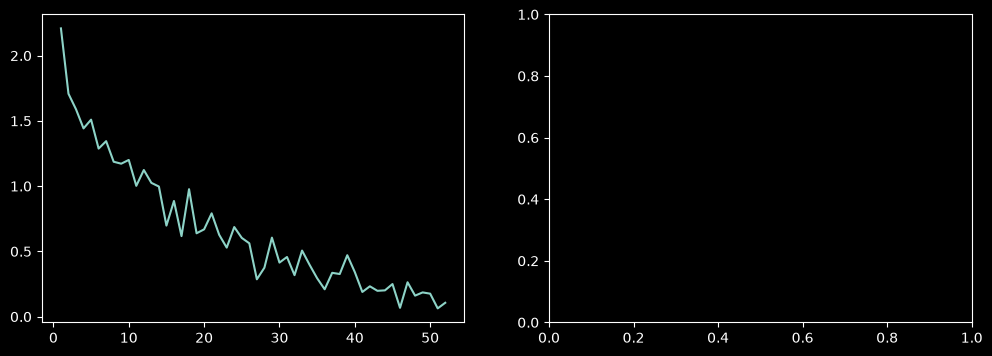

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

m = metrics_cb.metrics
epochs = range(1, len(m["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, m["train_loss"], label="train")
ax1.plot(epochs, m["val_loss"], label="val")
ax1.set_title("Loss")
ax1.set_xlabel("epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, m["train_acc"], label="train")
ax2.plot(epochs, m["val_acc"], label="val")
ax2.set_title("Accuracy")
ax2.set_xlabel("epoch")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()